
<p style="font-size:50px">
<span style="font-size:200px">
&#9703;
</span>
La similarité cosinus
</p>

---



Sous-sections :
[Définition](#def)&nbsp;|
[Produit scalaire](#scal)&nbsp;|
[Norme](#norme)&nbsp;|
[Angle](#angle)&nbsp;|
[Application sur des données images](#images)&nbsp;

<a id="def"></a>
### Définition

Une façon d'évaluer la similarité entre deux vecteurs
$\overrightarrow{a}$ et $\overrightarrow{b}$ est de calculer
le cosinus de l'angle formé par les deux vecteurs, dont la formule est
donnée par :

![](../images/cosin.png) 

In [1]:
a = (3,4)
b = (-3,5)

<a id="scal"></a>
### Produit scalaire

Compléter la fonction `dot` suivante qui calcule le produit scalaire
$\overrightarrow{u}.\overrightarrow{v}$ entre deux vecteurs $\overrightarrow{u}$ et $ \overrightarrow{v}$.

In [ ]:
def dot(u,v):
    # <- completer ici
    ...

# --------- tests -------- #
try:
    assert dot(a,b)==11.0, 'Erreur : le produit scalaire entre les vecteurs a et b doit valoir 11.0.'
    print("Ok")
except AssertionError as e:
    print(e)   

<a id="norme"></a>
### Norme

La fonction norm suivante permet de calculer la norme Euclidienne $\left\lVert\overrightarrow{u}\right\rVert$ d'un vecteur $\overrightarrow{u}$:


In [ ]:
import math
def norm(u):
    # <- completer ici
    ...

# --------- tests -------- #
try:
    assert norm(a)==5.0, 'Erreur : la norme de a doit valoir 5.0.'
    print("Ok")
except AssertionError as e:
    print(e)   

Ici, la fonction math.sqrt renvoie la racine carré du nombre qu'on lui donne en paramètre.
    
On appelle la fonction norm de la manière suivante, en lui passant en paramètre un vecteur, par exemple le vecteur a :
```Python
norm(a)
```

<a id="cosinus"></a>
### Similarité cosinus

Utiliser les fonctions dot et norm pour calculer la similarité cosinus entre les deux vecteurs $\overrightarrow{a}=(3,4)$ et $\overrightarrow{b}=(-3,5)$.


In [ ]:
def cosin(u,v):
    # <- completer ici
    ...
    
# --------- tests -------- #
try:
    assert cosin(a,b)==0.37729688731351946, 'Erreur : le cosinus de l\'angle entre les vecteurs a et b doit valoir 0.37729688731351946 '
    print("Ok")
except AssertionError as e:
    print(e)   

Ok


<a id="angle"></a>
### Angle

On peut aussi calculer l'angle en degrés à partir du cosinus.

Calculer l'angle en degrés entre les vecteurs $\overrightarrow{a}=(3,4)$ et $\overrightarrow{b}=(-3,5)$.

In [ ]:
import math 
def angle(u,v):
    # <- completer ici
    ...

# --------- tests -------- #
try:
    assert angle((0,1),(-1,1))==45.00000000000001, 'Erreur : l\'angle entre les vecteurs (0,1) et(-1,1) doit valoir 45 ° '
    assert angle((1,0),(-1,0))==180, 'Erreur : l\'angle entre les vecteurs (1,0) et(-1,0) doit valoir 180 ° '
    assert angle(a,b)==67.83365417791754, 'Erreur : l\'angle entre les vecteurs a et b doit valoir 67.83365417791754 ° '
    print("Ok")
except AssertionError as e:
    print(e)   


<a id="images"></a>
### Application au calcul de similarité entre deux images


Nous allons utiliser cette mesure de similarité pour trouver l'image la plus (resp.,  la moins) similaire à une image donnée.

Nous travaillons ici sur des images de radiologie : https://www.kaggle.com/datasets/kmader/siim-medical-images/data

On charge toutes les images :

In [ ]:
import numpy as np
data = np.load('../data/ct_images/full_archive.npz', allow_pickle=True)
images = data['image'] # the 512x512 images
indices = data['idx']

On peut visualiser la première image :

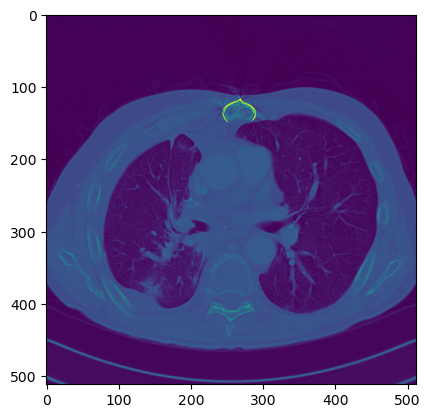

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(images[0])

Chaque image est un objet de type `numpy.ndarray` :

In [32]:
image = images[0]
image, image.shape

(array([[ -973.,  -997., -1024., ...,  -993.,  -979.,  -995.],
        [ -985.,  -977., -1023., ...,  -964., -1024., -1022.],
        [ -973., -1019., -1014., ..., -1024.,  -942.,  -961.],
        ...,
        [-1024.,  -971.,  -935., ..., -1023.,  -989.,  -994.],
        [ -954.,  -928., -1024., ...,  -965., -1024.,  -980.],
        [ -997.,  -996., -1024., ...,  -882.,  -973., -1001.]],
       shape=(512, 512)),
 (512, 512))

On peut l'applatir pour obtenir une vecteur :

In [33]:
image.flatten()

array([ -973.,  -997., -1024., ...,  -882.,  -973., -1001.],
      shape=(262144,))

On peut alors calculer la similarité cosin entre l'image 0 et l'image 1 :

In [46]:
cosin(image[0].flatten(),image[1].flatten())

np.float64(0.9984201040996036)

Parmi les 30 premières images, quelle est l'image la plus similaire à la $16^e$ image ?

Quelle est l'image la moins similaire ? 

Afficher ces images.

In [ ]:
cible_idx = 15
# <- completer ici
...


On affiche ces images :

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=3,figsize=(16, 8), dpi=100)
axes[0].imshow(images[cible_idx])
axes[0].set_title('Image initiale')
axes[1].imshow(images[idx_max])
axes[1].set_title(f'Image la plus similaire (i={idx_max})')
axes[2].imshow(images[idx_min])
axes[2].set_title(f'Image la moins similaire (i={idx_min})')